# Eos Simulation
by Finn Breuer and Ricardo Reinke  
HALO - Hamburg Space Team e.V.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from CoolProp.CoolProp import PropsSI

## Configuration

### Simulation Set up

In [2]:
t_0 = 0.0  # initial time in seconds [s]
t = t_0  # set time to initial time
delta_t = 0.001  # timestep in seconds [s]
t_sim_max = 60.0  # maximum simulation time in seconds [s]

dV = 0.0001  # volumestep in cubic meters [m^3]

### Rocket Sizing

In [3]:
c_d = 0.8  # drag coefficient []

#### Tank

**Concentric arrangement:** The fuel tank is submerged inside the oxidizer tank, and its volume will be subtracted from the internal volume of the oxidizer tank.

In [4]:
# Oxidizer (NO2) tank
D_tank_NO2_outer = 0.11  # outer diameter of the oxidizer tank in meter [m]
t_tank_NO2 = 0.004  # wall thickness of the oxidizer tank in meter [m]
D_tank_NO2_inner = D_tank_NO2_outer - 2*t_tank_NO2  # inner diameter of the oxidizer tank in meter [m]
l_tank_NO2 = 1.0  # length of the oxidizer tank in meter [m]

# Fuel tank
D_tank_fuel_outer = 0.06  # outer diameter of the fuel tank in meter [m]
t_tank_fuel = 0.0015  # wall thickness of the fuel tank in meter [m]
D_tank_fuel_inner = D_tank_fuel_outer - 2*t_tank_fuel  # inner diameter of the fuel tank in meter [m]
l_tank_fuel = 1.0  # length of the fuel tank in meter [m]

# Volumes
A = np.pi/4 * D_tank_NO2_outer
V_tank_NO2 = np.pi/4 * D_tank_NO2_inner**2 * l_tank_NO2 - np.pi/4 * D_tank_fuel_outer**2 * l_tank_fuel  # inner volume of the oxidizer tank (excluding the fuel tank) in cubic meters [m^3]
V_tank_fuel = np.pi/4 * D_tank_fuel_inner**2 * l_tank_fuel  # inner volume of the fuel tank in cubic meters [m^3]

# Masses
rho_alu = 2700.0  # density of aluminium [kg/m^3]
V_tank_dry = np.pi/4 * l_tank_NO2 * (D_tank_NO2_outer**2 - D_tank_NO2_inner**2) + np.pi/4 * l_tank_fuel * (D_tank_fuel_outer**2 - D_tank_fuel_inner**2)  # material volume for tanks in cubic meters [m^3]
m_tank_dry = V_tank_dry * rho_alu  # dry mass of the tank [kg]

rho_NO2 = 852  # density of the oxidizer [kg/m^3]
m_tank_NO2 = V_tank_NO2 * rho_NO2  # mass of oxidizer [kg]

rho_fuel = 779  # density of the fuel [kg/m^3]
m_tank_fuel = V_tank_fuel * rho_fuel  # mass of fuel [kg]

m_tank_wet = m_tank_dry + m_tank_NO2 + m_tank_fuel  # wet mass [kg]
print('m_tank_wet =', round(m_tank_wet, 2), 'kg')
print('m_tank_dry =', round(m_tank_dry, 2), 'kg')

OF = m_tank_NO2 / m_tank_fuel  # The OF is the ratio of oxidizer and fuel stored in the tank. []
print('OF =', round(OF,2))
print('V_tank_NO2 =', round(V_tank_NO2,4), 'm^3')
print('m_tank_NO2 =', round(m_tank_NO2,2), 'kg')

m_tank_wet = 10.88 kg
m_tank_dry = 4.34 kg
OF = 2.29
V_tank_NO2 = 0.0053 m^3
m_tank_NO2 = 4.55 kg


#### Orifices  

In [5]:
oCount = 16  # orifice count
oArea = 0.0000064  # orifice area in square meters [m^2]

a0 = oCount * oArea  # total orifice area in square meters [m^2]

Cd = 0.75  # injector Cd (dimensionless)

### Environmental Conditions

#### Constants

In [6]:
R_E = 6371000.0  # radius Earth in meter [m]
g = 9.80665  # gravitational constant [m/s^2]

#### International Standard Atmosphere - ISA

In [7]:
h_0 = 0.0  # reference altitude (MSL) in meter [m]
p_0 = 101325.0  # standard pressure at MSL in Pascal [Pa]
T_0 = 288.15  # standard Temperature at MSL in Kelvin [K]
R_air = 287.07  # specific gaseous constant of air in J/(kg*K)
rho_air = 1.050  # density of air

def get_temperature_gradient(altitude: float) -> float:
    """
    Calculates the temperature gradient T_grad for a given altitude
    :param altitude: Altitude above MSL in meters [m].
    :return: Temperature gradient in Kelvin per meter [K/m].
    """
    if altitude < 0:
        raise ValueError('Altitude cannot be negative.')
    # Troposphere (up to 11 km)
    if altitude <= 11000:
        T_grad = -0.0065
        
    # Lower Stratosphere / Tropopause (11 km to 20 km)
    elif altitude <= 20000:
        T_grad = 0.0
        
    # Middle Stratosphere (above 20 km)
    else:
        T_grad = 0.001

    return T_grad


def get_pressure(altitude: float, temperature: float) -> float:
    """
    Calculates the pressure p for a given altitude 
    :param altitude: Altitude above MSL in meters [m].
    :param temperature: Temperature in Kelvin [K]
    :return: Pressure in Pascal [Pa].
    """
    T_grad = get_temperature_gradient(altitude=altitude)
    p = p_0 * (1+(T_grad*(altitude-h_0))/temperature)**(-g/(R_air*T_grad))
    return p

#### Ground Conditions

In [8]:
alt_ground = 73.0  # set altitude over MSL in meter, 73 m Flugplatz Höpen (Schneverdingen)
T_ground = 293.15  # Temperature in Kelvin [K]
p_ground = get_pressure(altitude=alt_ground, temperature=T_ground)  # pressure at ground in Pascal [Pa]

## Filling

Filling from NO2 supply to NO2 tank tbd

## Launch

 --------------------------------------------------------------
 By Aadam Awad for the Columbia Space Initiative Rocketry Team
 --------------------------------------------------------------

 The goal of this program is to perform numerical simulations to approximate the behavior of
 liquid NitrousOxide through a choked injecotr for a NitrousOxide hybrid rocket
 motor. It uses the REFPROP library, interfacing in Python via CoolProp, and displays the
 data in Matplotlib. This program should produce an approximate graph
 of pressure vs. time given several fixed constraints: injector CdA, NitrousOxide mass, and
 outside temperature as initial conditions.

 This is the second version of this model, designed to approximate tank blowdown while
 incorporating compressibility of both the vapor and NitrousOxide.
 Additionally, this model is modifying the mass discharge parameters to be based on an
 injector CdA rather than a fixed mass flow rate. This leaves
 more free variables to be tweaked before finalizing engine design, but will produce more
 accurate results and produce an accurate mass flow rate vs. time graph.

 Assumptions to simplify the model:
 - Heat transfer through the plumbing to the NitrousOxide is second order during blowdown
 - The NitrousOxide remains saturated throughout the burn (rate of boil-off is greater than
 rate of discharge). Empirical tests have shown this is valid
 for initial ullage volume ratios exceeding 10-20%.
 - The bulk liquid nitrous is the same temperature throughout the burn (there is no
 temperature gradient between different regions of the liquid nitrous)
 - All choking occurs at the injector (modeled by Burnells) and the rest of the plumbing is
 sufficiently sized such that no choking occurs

https://www.aadamawad.com/blowdown-simulations/

In [9]:
T_ground = 293.15  # expected tank temperature at launch in Kelvin [K]
V_tank_NO2 = 0.007  # Total tank volume in m^3

sys.setrecursionlimit(50000)

outputData = {
    "density": [],
    "temperature": [],
    "pressure": [],
    "massflow": [],
    "time": []
}

### Defining Initial States of the Bulk Fluid and Vapor
Calculates the pre-calculation of Vapor Compressibility Z for temperature T_ground and Quality Factor Q=1 (NO2 saturated vapor)

In [30]:
Q_init = PropsSI("Z", "T", T_ground, "Q", 1, "NitrousOxide")  

def get_init_params_NO2(V_tank_NO2_liquid, V_tank_NO2_vapor): 
    V_tank_NO2_liquid_new = V_tank_NO2_liquid + dV
    V_tank_NO2_vapor_new = V_tank_NO2_vapor - dV
    m_tank_NO2_liquid_new = V_tank_NO2_liquid_new * PropsSI("D", "T", T_ground, "Q", 0, "NitrousOxide")
    m_tank_NO2_vapor_new = V_tank_NO2_vapor_new * PropsSI("D", "T", T_ground, "Q", 1, "NitrousOxide") / Q_init

    if m_tank_NO2_liquid_new >= m_tank_NO2:
        return V_tank_NO2_liquid_new, V_tank_NO2_vapor_new, m_tank_NO2_liquid_new, m_tank_NO2_vapor_new, (m_tank_NO2_liquid_new + m_tank_NO2_vapor_new) # Initial liquid volume, vapor volume, and total mass reading for the load cell

    return get_init_params_NO2(V_tank_NO2_liquid_new, V_tank_NO2_vapor_new)

V_tank_NO2_liquid, V_tank_NO2_vapor, m_tank_NO2_liquid, m_tank_NO2_vapor, m_tank_NO2_total = get_init_params_NO2(0, V_tank_NO2)
print(
    f"NO2 Tank\n"
    f"Q_init:       {Q_init:.2f} \n"
    f"V_liquid:     {V_tank_NO2_liquid:.4f} m^3\n"
    f"V_vapor:      {V_tank_NO2_vapor:.4f} m^3\n"
    f"m_liquid:     {m_tank_NO2_liquid:.4f} kg\n"
    f"m_vapor:      {m_tank_NO2_vapor:.4f} kg\n"
    f"m_total:      {m_tank_NO2_total:.4f} kg"
)

NO2 Tank
Q_init:       0.58 
V_liquid:     0.0058 m^3
V_vapor:      0.0012 m^3
m_liquid:     4.5536 kg
m_vapor:      0.3283 kg
m_total:      4.8819 kg


### Blowdown Iterative Model

In [11]:
def burnellEmpCoeff (press): # Linear approximation for the empirical coefficient C for Burnell's equation.
    return -0.000000015267*press + 0.2279

def injectorMassFlow (T): # Calculates the volumetric flow rate per unit time dV/dt across the injector
    press = PropsSI("P", "T", T, "Q", 0, "NitrousOxide")
    dens = PropsSI("D", "T", T, "Q", 0, "NitrousOxide")
    mDot = Cd*a0*np.sqrt(2*dens*(press - press*(1 - burnellEmpCoeff(press)))) # Burnell's equation
    return mDot

def vaporizationH (T): # Enthalpy of vaporization for NitrousOxide
    return PropsSI("H", "T", T, "Q", 1, "NitrousOxide") - PropsSI("H", "T", T, "Q", 0, "NitrousOxide")

def specificHeat (T): # Isobaric specific heat capacity of NitrousOxide
    return PropsSI("C", "T", T, "Q", 1, "NitrousOxide")

def main (): # Performs the blowdown calculations
    curLiqVol = V_tank_NO2_liquid
    curVapVol = V_tank_NO2_vapor
    curTemp = T_ground
    curPress = PropsSI("P", "T", T_ground, "Q", 0, "NitrousOxide")
    print(curPress)

    inEquilibrium = False
    tracker = 0

    while curLiqVol >= 0.0001:

        dens = PropsSI("D", "T", curTemp, "Q", 0, "NitrousOxide")
        mDot = injectorMassFlow(curTemp)
        deltaV = (mDot / dens) * delta_t # Changed timeStep to delta_t

        if (inEquilibrium == True): # The system is in equilibrium, so we can remove some volume.
            tracker += 1
            outputData["time"].append (tracker * delta_t) # **Änderung:** timeArr zu outputData["time"]

            curPress = curPress * (curVapVol / (curVapVol + deltaV))
            outputData["pressure"].append (curPress) # **Änderung:** pressArr zu outputData["pressure"]

            curLiqVol -= deltaV
            curVapVol += deltaV * PropsSI("Z", "T", curTemp, "Q", 0, "NitrousOxide")

            outputData["massflow"].append (mDot) # **Änderung:** massFlowArr zu outputData["massflow"]

            # Speichern der restlichen Parameter, wenn im Gleichgewicht
            outputData["temperature"].append(curTemp)
            outputData["density"].append(dens)
            
            inEquilibrium = False

        else:
            massSlice = deltaV / 0.01
            curVapVol += massSlice * PropsSI("Z", "T", curTemp, "Q", 1, "NitrousOxide") / PropsSI("D", "T", curTemp, "Q", 0, "NitrousOxide")
            curTemp = curTemp - (massSlice/(curLiqVol*dens)) * (vaporizationH(curTemp) /specificHeat(curTemp))

            curVapMass = curVapVol * PropsSI("D", "P", curPress, "Q", 1, "NitrousOxide")
            curPress = curPress * (1 + massSlice / curVapMass)

            tempPress = PropsSI("P", "T", curTemp, "Q", 0, "NitrousOxide")

            if (curPress >= tempPress):
                inEquilibrium = True

main()

5052509.283082383


Graphical Interface

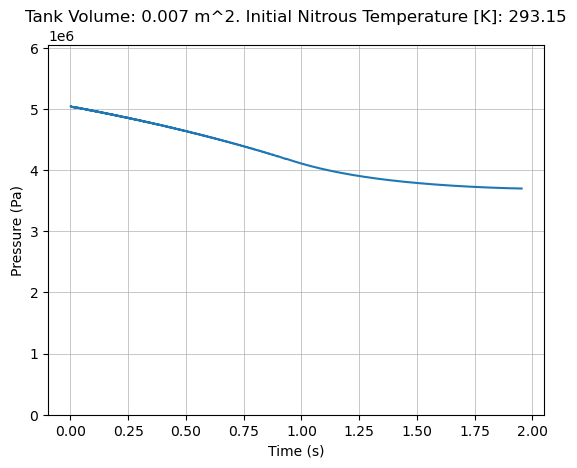

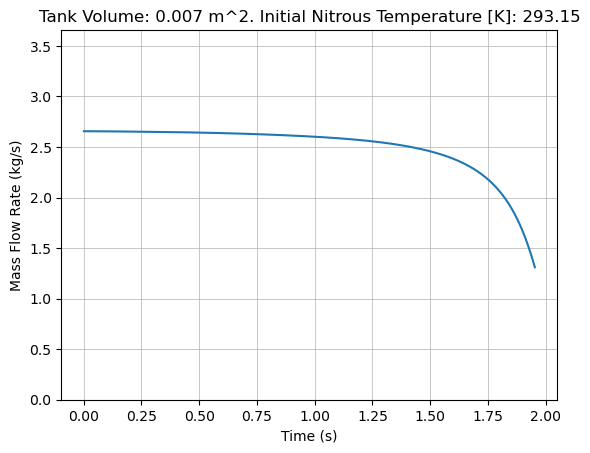

In [12]:
plt.figure(1)

maxValPress = max(outputData["pressure"])

plt.ylim(0, maxValPress + 10e5)
plt.plot(outputData["time"], outputData["pressure"])
plt.xlabel('Time (s)')
plt.ylabel('Pressure (Pa)')
plt.title('Tank Volume: ' + str(V_tank_NO2) + ' m^2. Initial Nitrous Temperature [K]: ' + str(T_ground))
plt.grid(linewidth = '0.5')

plt.figure(2)

maxValMDot = max(outputData["massflow"])

plt.ylim(0, maxValMDot + 1)
plt.plot(outputData["time"], outputData["massflow"])
plt.xlabel('Time (s)')
plt.ylabel('Mass Flow Rate (kg/s)')
plt.title('Tank Volume: ' + str(V_tank_NO2) + ' m^2. Initial Nitrous Temperature [K]: ' + str(T_ground))
plt.grid(linewidth = '0.5')

plt.show()

In [13]:
t_b = 2  # burn time in seconds [s]
I = 120  # specific impulse [s]
m_prop = m_tank_NO2 + m_tank_fuel  # propellant fuel
m_dot = m_prop/t_b  # mass flow rate
m = m_tank_wet
v = 0.0
z = alt_ground
F = I * m_dot * g
data_t = []
data_z = []

In [14]:
while t < t_sim_max:
    if t > t_b:
        F = 0
        
    D = 1/2 * rho_air * v**2 * A * c_d * np.sign(v)

    if t < t_b:
        m = m - m_dot * delta_t
        
    else:
        m = m_tank_dry
    W = m * g
    
    F_net = F - D - W 

    a = F_net / m

    v = v + a * delta_t

    z = z + v * delta_t

    if z <= alt_ground:
        break
    
    t = t + delta_t

    data_t.append(t)
    data_z.append(z)
    
print('Simulation finished t >= t_sim_max')

Simulation finished t >= t_sim_max


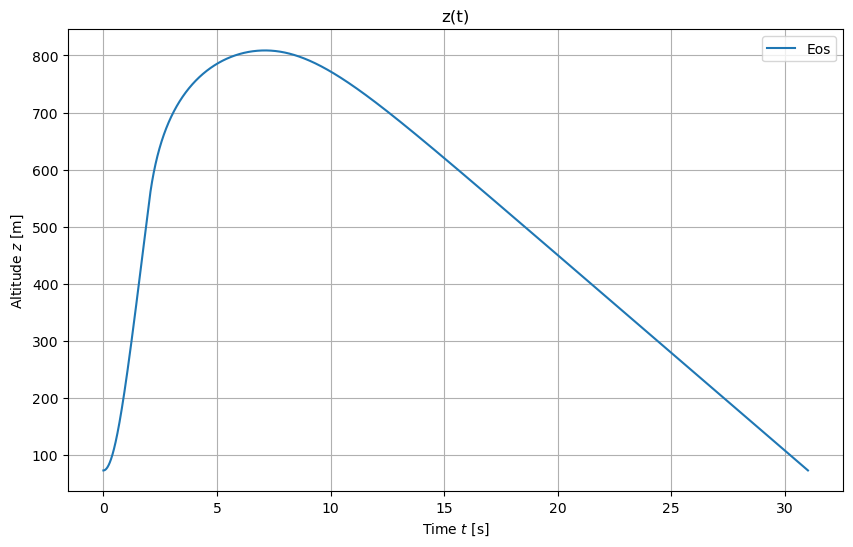

In [15]:
def plot_results(data_t, data_z):
    """Create the z(t) plot"""
    
    plt.figure(figsize=(10, 6))

    plt.plot(data_t, data_z, label='Eos')
    
    plt.title('z(t)')
    plt.xlabel('Time $t$ [s]')
    plt.ylabel('Altitude $z$ [m]')
    
    plt.grid(True)
    plt.legend()
    
    plt.show()

plot_results(data_t, data_z)